In [8]:
import numpy as np
import matplotlib.pyplot as plt
from kicked_rotor import floquet_kicked_rotor, floquet_kicked_harper
from scipy.special import gamma
from scipy.optimize import curve_fit

plt.rcParams["text.usetex"] = True
plt.rcParams["figure.dpi"] = 150

In [9]:
def quasienergy_spacings(U):
    phases = np.angle(np.linalg.eigvals(U)) % (2 * np.pi)
    phases = np.sort(phases)
    raw = np.append(np.diff(phases), phases[0] + 2*np.pi - phases[-1])
    return raw * (len(phases) / (2 * np.pi))


def collect_spacings(N, alpha, beta, kappa, num_realizations, model):
    floquet = floquet_kicked_rotor if model.lower() == "rotor" else floquet_kicked_harper
    all_spacings = []

    for _ in range(num_realizations):
        if beta is None:
            # draw beta away from time-reversal symmetric points
            b = np.random.uniform(0.1, 0.4)
        else:
            b = beta
        U = floquet(N, alpha, b, kappa)
        if np.allclose(U, U.T, atol=1e-3) == True:
            print("GOE")
        elif np.allclose(U, U.T.conj(), atol=1e-3) == True:
            print("GUE")
        else:
            print("None of the symmetry classes hold. HUH")
        all_spacings.append(quasienergy_spacings(U))

    return np.concatenate(all_spacings)


def p_poisson(s):
    return np.exp(-s)

def poisson(a, s):
    return a * np.exp(-s)

def goe(A, B, s):
    return A * s * np.exp(-B * s**2)

def gue(A, B, s):
    return A * s * np.exp(-B * s**2)

def wigner_dyson(s, beta):
    B = (gamma((beta + 2) / 2) / gamma((beta + 1) / 2))**2
    A = 2 * B**((beta + 1) / 2) / gamma((beta + 1) / 2)
    return A * s**beta * np.exp(-B * s**2)

In [10]:
MODEL    = "rotor"
MODEL0   = "harper"
N        = 1009
NUM_REAL = 1
BINS     = 30
s_vals   = np.linspace(0, 4, 300)

In [11]:
def spacing_dist(N, alpha, beta, K, n, model, stats_model, stats_name):

    s = collect_spacings(N, alpha, beta, K, n, model)
    counts, _, _ = plt.hist(s, bins = BINS, histtype = 'step', color = 'black', label = r'$P(s)$')
    
    # fit the curve
    pars, cov = curve_fit(stats_model, s_vals, counts, )

None of the symmetry classes hold. HUH


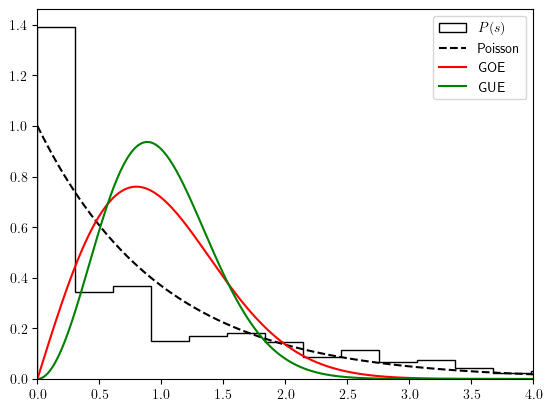

None of the symmetry classes hold. HUH


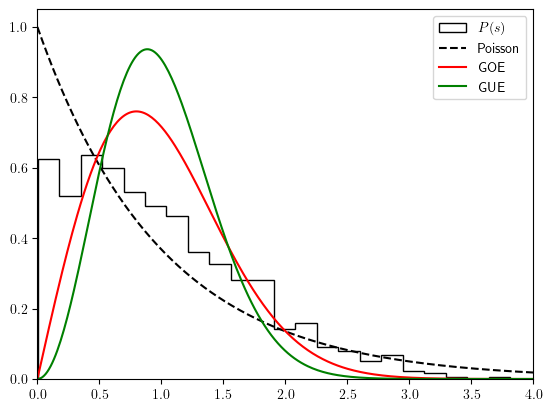

None of the symmetry classes hold. HUH


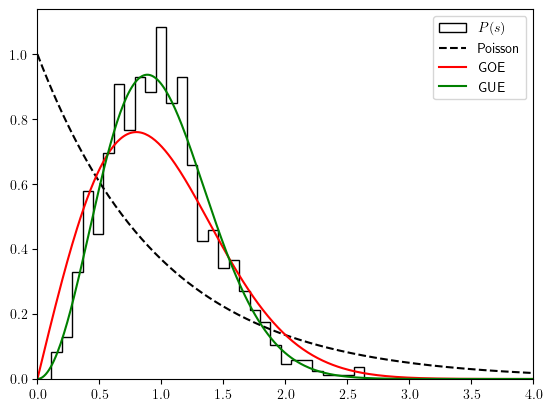

In [5]:
# integrable case

K1 = 0.05
alpha1 = 0; beta1 = 0

spacings1 = collect_spacings(N, 0, 0, K1, 1, MODEL0)
plt.hist(spacings1, bins = BINS, density = True, histtype = 'step', color = 'black', label = r'$P(s)$')
plt.plot(s_vals, p_poisson(s_vals),       "k--", label="Poisson")
plt.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  label="GOE")
plt.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  label="GUE")
plt.xlim(0, 4)
plt.legend()
plt.show()

# GOE

K2 = 10
alpha2 = 0; beta2 = 0

spacings2 = collect_spacings(N, 0, 0, K2, 1, MODEL0)
plt.hist(spacings2, bins = BINS, density = True, histtype = 'step', color = 'black', label = r'$P(s)$')
plt.plot(s_vals, p_poisson(s_vals),       "k--", label="Poisson")
plt.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  label="GOE")
plt.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  label="GUE")
plt.xlim(0, 4)
plt.legend()
plt.show()

# GUE

K3 = 10
alpha3 = 0; beta3 = 0

spacings3 = collect_spacings(N, 0.3, 0.6, K3, 1, MODEL0)
plt.hist(spacings3, bins = BINS, density = True, histtype = 'step', color = 'black', label = r'$P(s)$')
plt.plot(s_vals, p_poisson(s_vals),       "k--", label="Poisson")
plt.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  label="GOE")
plt.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  label="GUE")
plt.xlim(0, 4)
plt.legend()
plt.show()

None of the symmetry classes hold. HUH


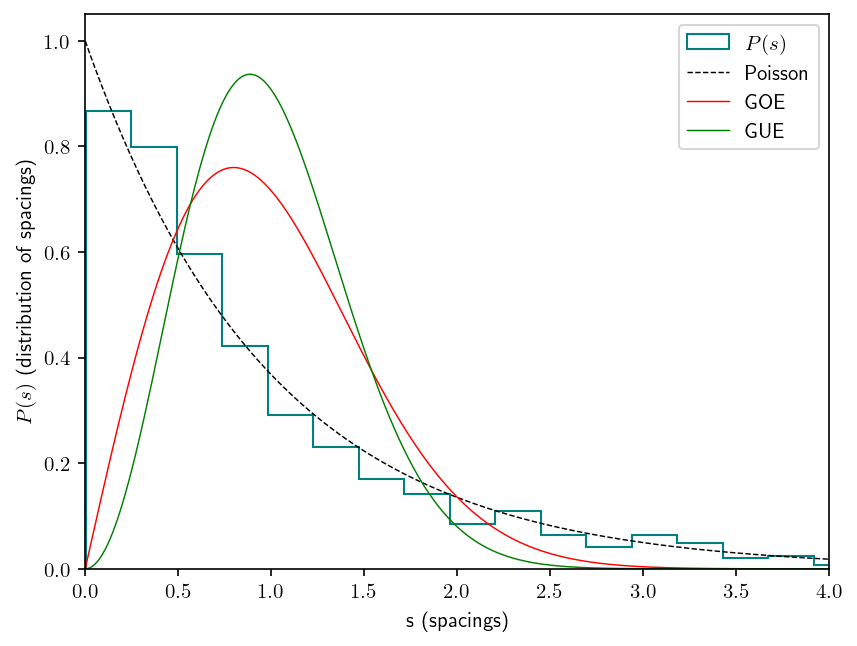

None of the symmetry classes hold. HUH


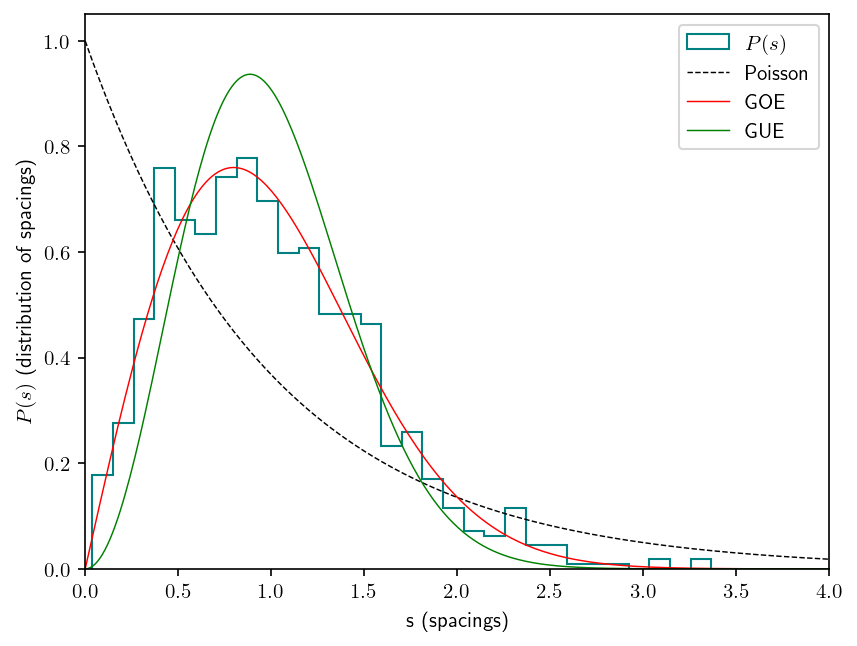

None of the symmetry classes hold. HUH


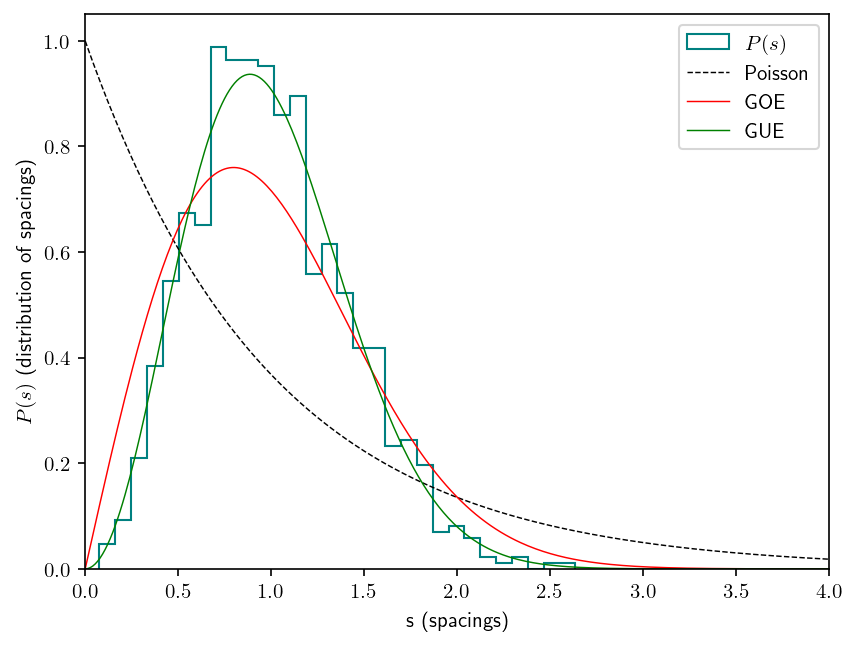

In [16]:
# integrable case

K1 = 0.05
alpha1 = 0; beta1 = 0

spacings1 = collect_spacings(N, 0, 0, K1, 1, MODEL)
plt.hist(spacings1, bins = BINS, density = True, histtype = 'step', color = 'teal', label = r'$P(s)$')
plt.plot(s_vals, p_poisson(s_vals),       "k--", lw = 0.7, label="Poisson")
plt.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  lw = 0.7, label="GOE")
plt.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  lw = 0.7, label="GUE")
plt.xlim(0, 4)
plt.xlabel(rf"s (spacings)")
plt.ylabel(rf"$P(s)$ (distribution of spacings)")
plt.legend()
plt.show()

# GOE

K2 = 10
alpha2 = 0; beta2 = 0

spacings2 = collect_spacings(N, 0, 0, K2, 1, MODEL)
plt.hist(spacings2, bins = BINS, density = True, histtype = 'step', color = 'teal', label = r'$P(s)$')
plt.plot(s_vals, p_poisson(s_vals),       "k--", lw = 0.7, label="Poisson")
plt.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  lw = 0.7, label="GOE")
plt.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  lw = 0.7, label="GUE")
plt.xlim(0, 4)
plt.xlabel(rf"s (spacings)")
plt.ylabel(rf"$P(s)$ (distribution of spacings)")
plt.legend()
plt.show()

# GUE

K3 = 10
alpha3 = 0; beta3 = 0

spacings3 = collect_spacings(N, 0.3, 0.6, K3, 1, MODEL)
plt.hist(spacings3, bins = BINS, density = True, histtype = 'step', color = 'teal', label = r'$P(s)$')
plt.plot(s_vals, p_poisson(s_vals),       "k--", lw = 0.7, label="Poisson")
plt.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  lw = 0.7, label="GOE")
plt.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  lw = 0.7, label="GUE")
plt.xlim(0, 4)
plt.xlabel(rf"s (spacings)")
plt.ylabel(rf"$P(s)$ (distribution of spacings)")
plt.legend()
plt.show()

None of the symmetry classes hold. HUH
None of the symmetry classes hold. HUH
None of the symmetry classes hold. HUH


/var/folders/c8/m11vsrv50cv5c2b0ljtrkgtw0000gn/T/ipykernel_42507/647124111.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


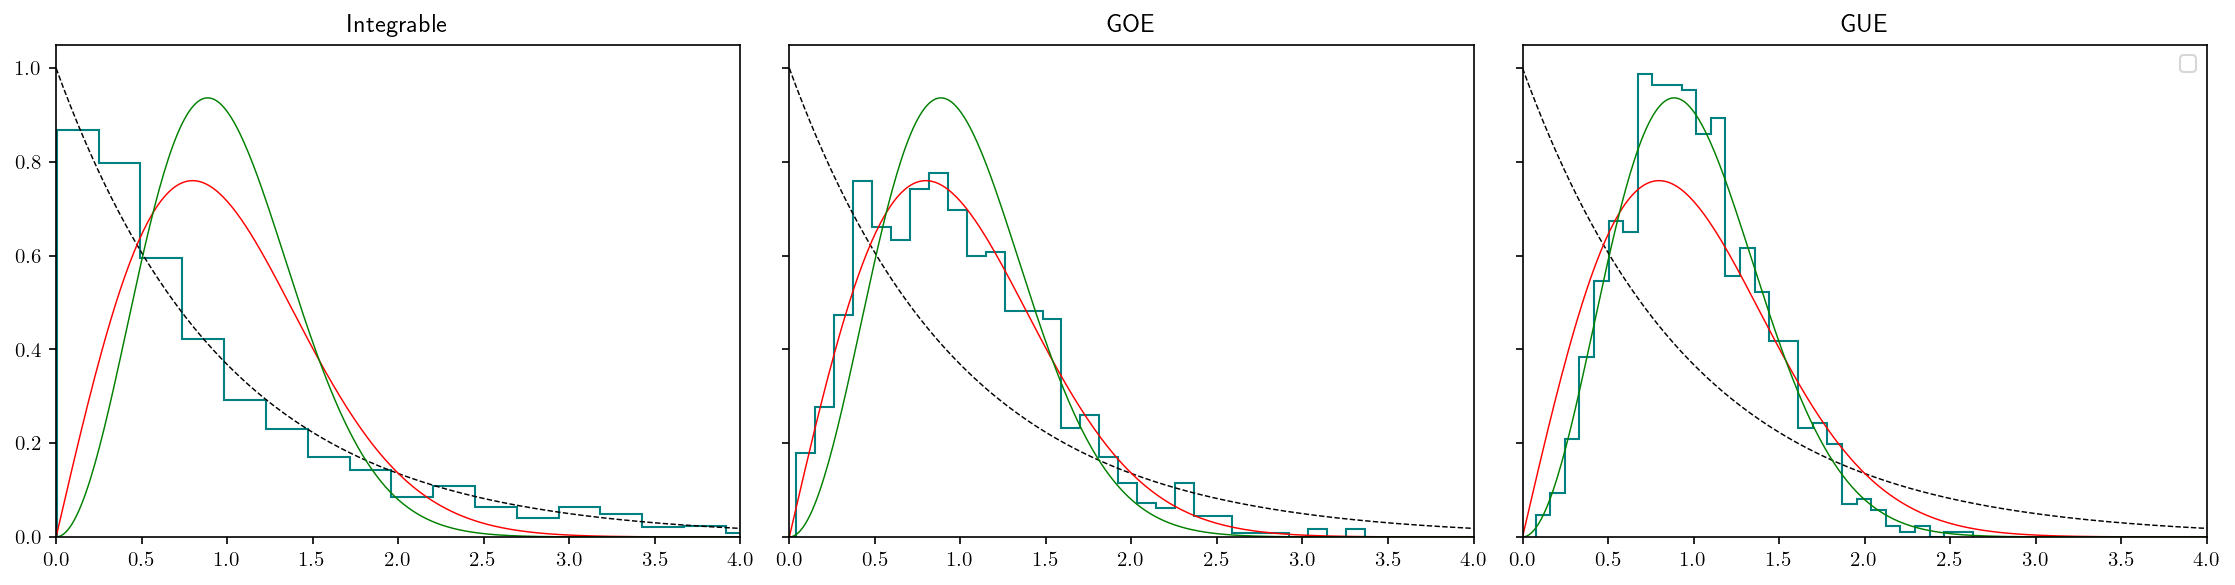

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# --- Integrable ---
K1 = 0.05
spacings1 = collect_spacings(N, 0, 0, K1, 1, MODEL)

axs[0].hist(spacings1, bins=BINS, density=True, histtype='step', color='teal', label=r'$P(s)$')
axs[0].plot(s_vals, p_poisson(s_vals),       "k--", lw=0.7, label="Poisson")
axs[0].plot(s_vals, wigner_dyson(s_vals, 1), "r-",  lw=0.7, label="GOE")
axs[0].plot(s_vals, wigner_dyson(s_vals, 2), "g-",  lw=0.7, label="GUE")
axs[0].set_xlim(0, 4)
axs[0].set_title("Integrable")

# --- GOE ---
K2 = 10
spacings2 = collect_spacings(N, 0, 0, K2, 1, MODEL)

axs[1].hist(spacings2, bins=BINS, density=True, histtype='step', color='teal')
axs[1].plot(s_vals, p_poisson(s_vals),       "k--", lw=0.7)
axs[1].plot(s_vals, wigner_dyson(s_vals, 1), "r-",  lw=0.7)
axs[1].plot(s_vals, wigner_dyson(s_vals, 2), "g-",  lw=0.7)
axs[1].set_xlim(0, 4)
axs[1].set_title("GOE")

# --- GUE ---
K3 = 10
spacings3 = collect_spacings(N, 0.3, 0.6, K3, 1, MODEL)

axs[2].hist(spacings3, bins=BINS, density=True, histtype='step', color='teal')
axs[2].plot(s_vals, p_poisson(s_vals),       "k--", lw=0.7)
axs[2].plot(s_vals, wigner_dyson(s_vals, 1), "r-",  lw=0.7)
axs[2].plot(s_vals, wigner_dyson(s_vals, 2), "g-",  lw=0.7)
axs[2].set_xlim(0, 4)
axs[2].set_title("GUE")

# shared legend (only once)
axs[2].legend()

plt.tight_layout()
plt.show()

None of the symmetry classes hold. HUH
None of the symmetry classes hold. HUH
None of the symmetry classes hold. HUH


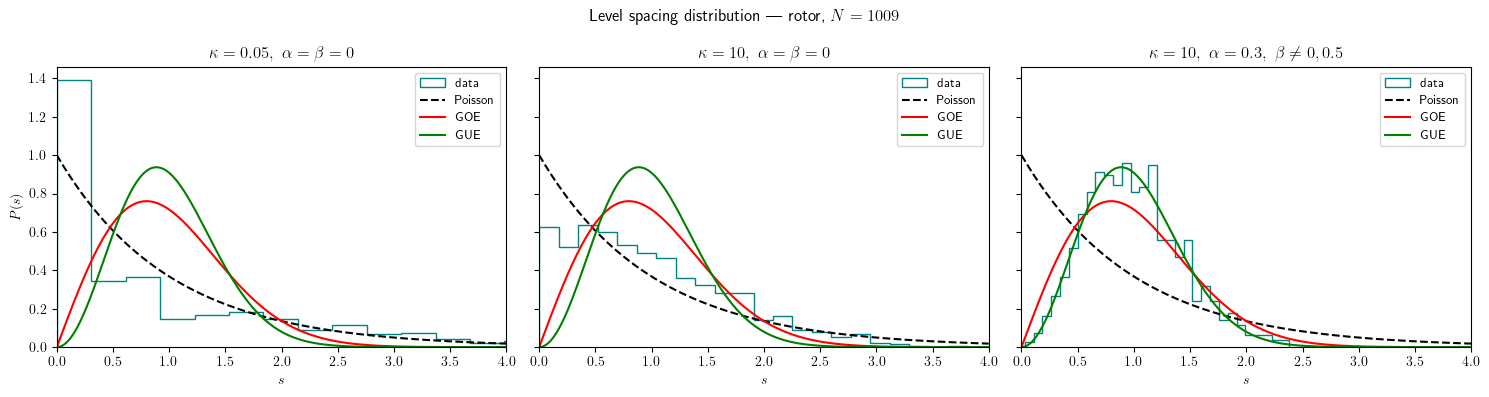

In [7]:
configs = [
    {"kappa": 0.05, "alpha": 0.0, "beta": 0.0,  "label": r"$\kappa=0.05,\ \alpha=\beta=0$"},
    {"kappa": 10, "alpha": 0.0, "beta": 0.0,  "label": r"$\kappa=10,\ \alpha=\beta=0$"},
    {"kappa": 10, "alpha": 0.3, "beta": None, "label": r"$\kappa=10,\ \alpha=0.3,\ \beta\neq 0,0.5$"},
]

# ── plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, cfg in zip(axes, configs):
    spacings = collect_spacings(N, cfg["alpha"], cfg["beta"],
                                cfg["kappa"], NUM_REAL, MODEL0)

    ax.hist(spacings, bins=BINS, density=True,
            histtype = 'step', color = 'teal', label="data")
    ax.plot(s_vals, p_poisson(s_vals),       "k--", label="Poisson")
    ax.plot(s_vals, wigner_dyson(s_vals, 1), "r-",  label="GOE")
    ax.plot(s_vals, wigner_dyson(s_vals, 2), "g-",  label="GUE")

    ax.set_title(cfg["label"])
    ax.set_xlabel(r"$s$")
    ax.set_xlim(0, 4)

axes[0].set_ylabel(r"$P(s)$")
axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)
axes[2].legend(fontsize=9)

plt.suptitle(rf"Level spacing distribution — {MODEL}, $N={N}$")
plt.tight_layout()
plt.show()